# Chat Templates: Talking to Instruction-Tuned Models the Right Way
### Tutorial 2 — Building on Hello, Small Language Models

---

In Tutorial 1 we sent a **raw text string** directly to the model and got back generated text. That work, but it is not how instruction-tuned models are designed to be used. This tutorial explains why, and introduces **chat templates**: the standard way to talk to models like LLaMA 3.2 Instruct.
---

## The Updated Pipeline
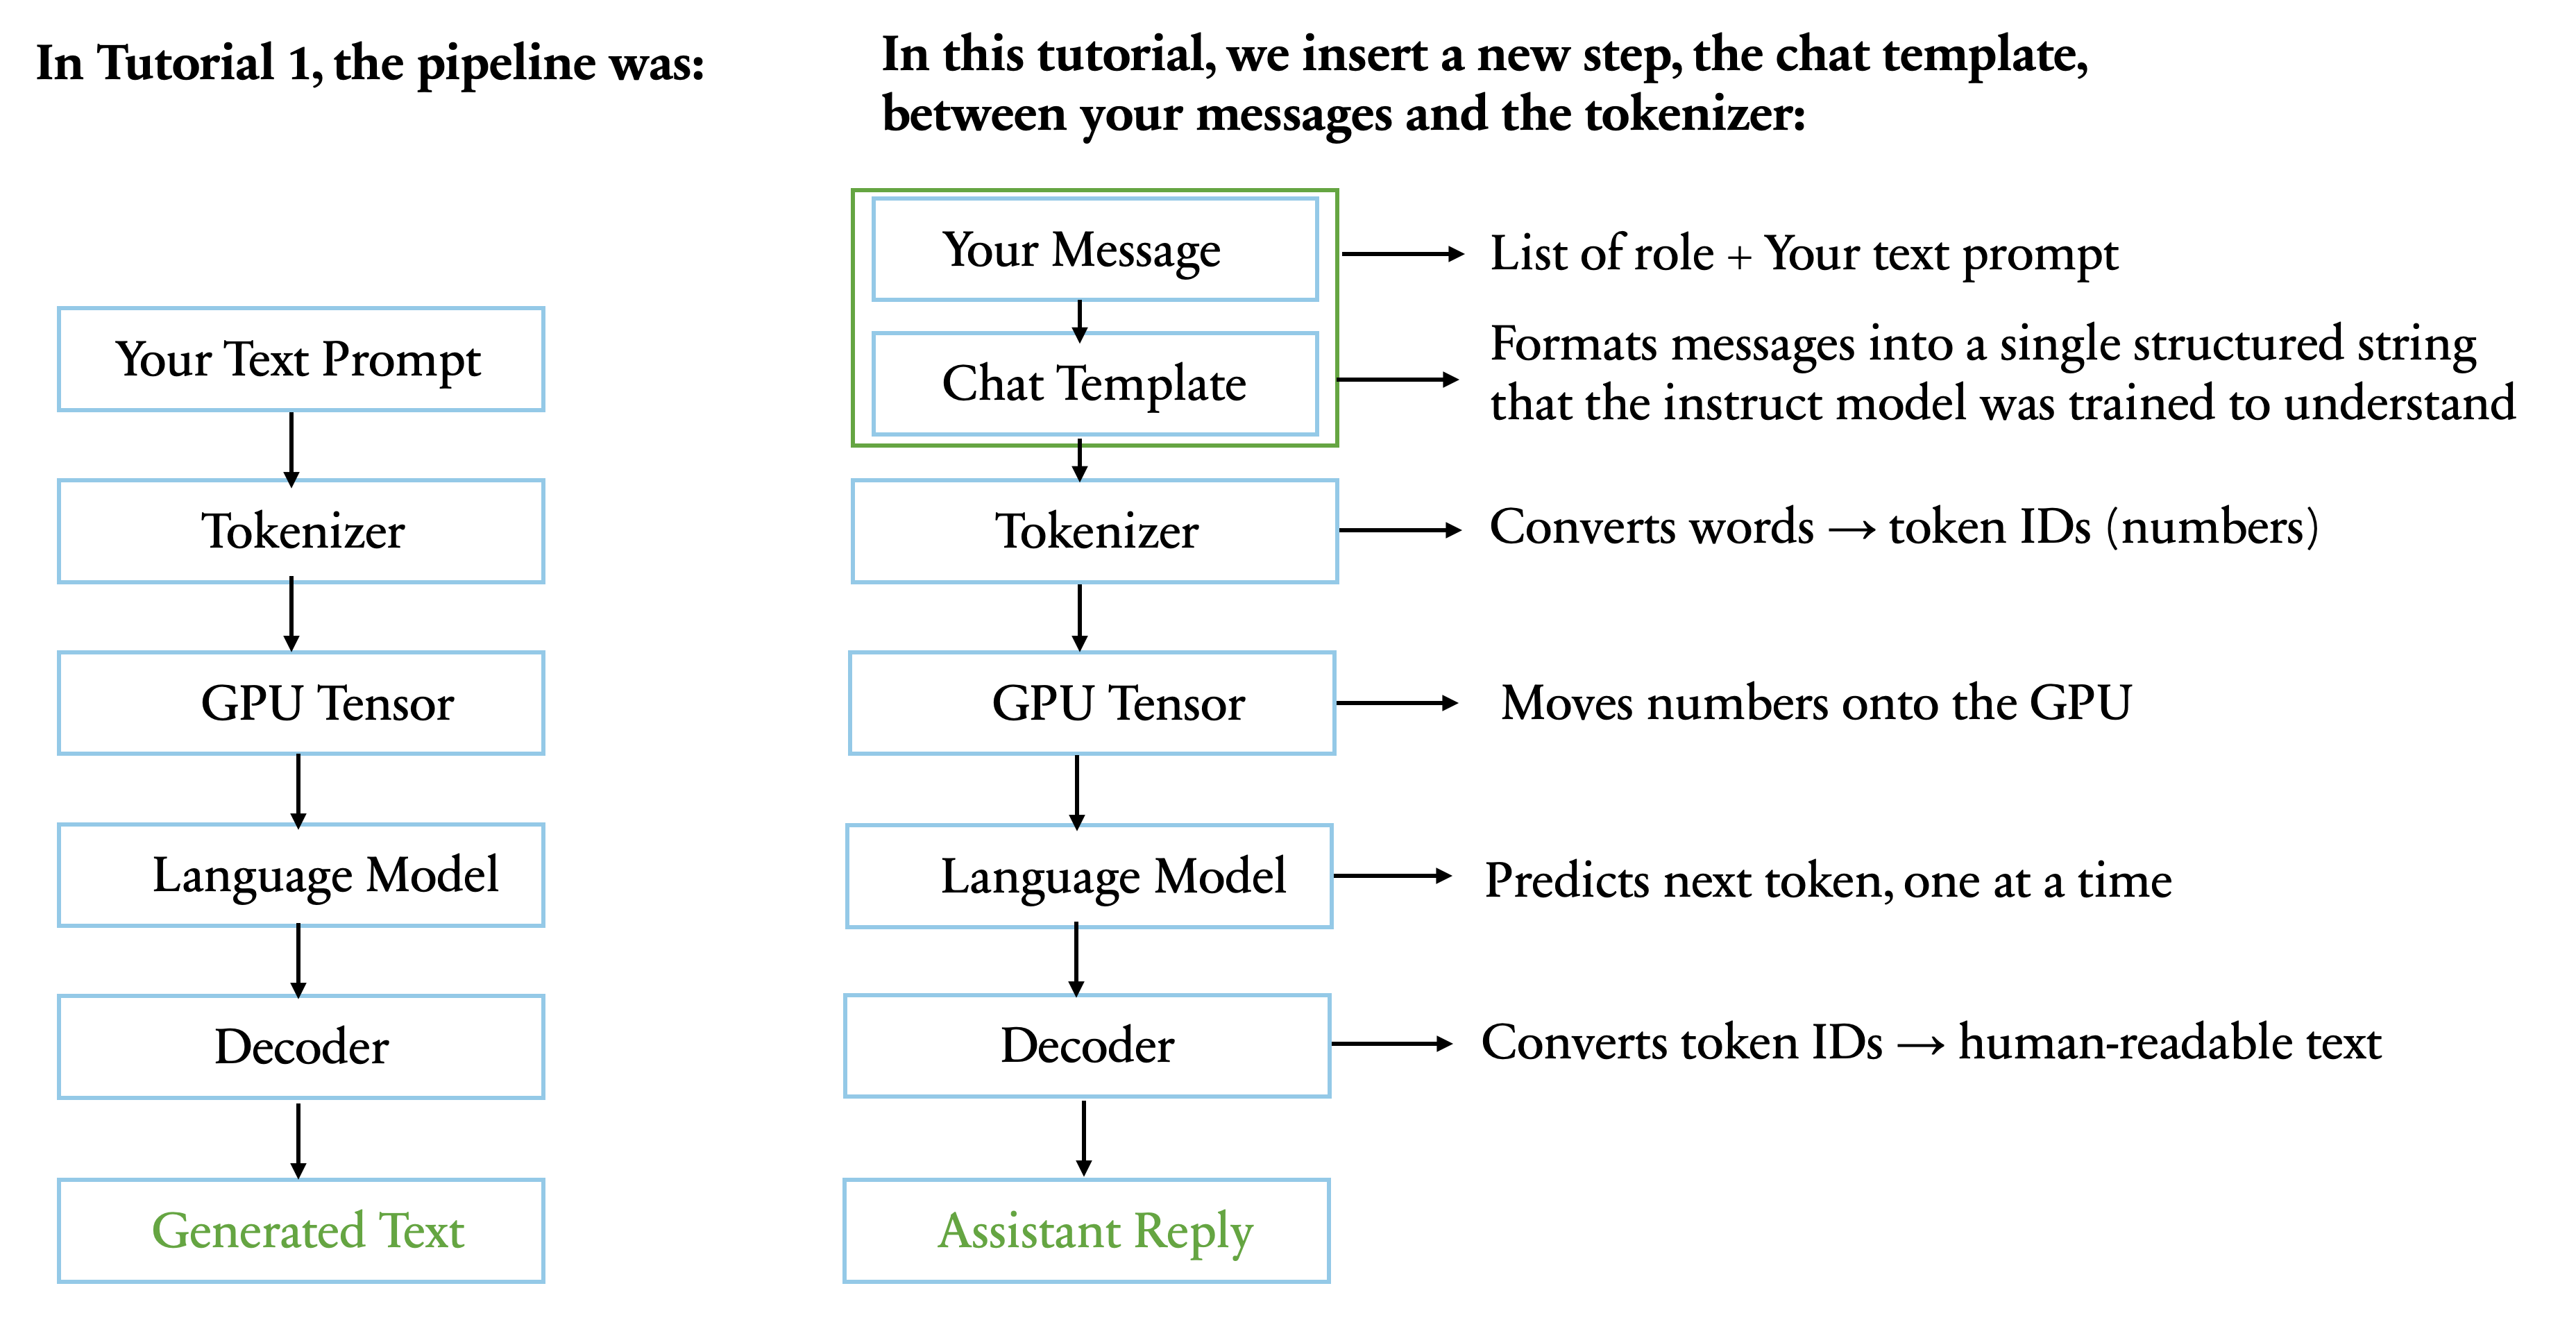


## What you will learn
- Limitation of  **raw text string** as prompts
- What a **chat template** is and why it exists
- How to structure a conversation using **roles** (`system`, `user`, `assistant`)
- How to use `apply_chat_template()` to format your messages correctly
- How to build **multi-turn conversations** (conversation history)
- How to use a **system prompt** to control the model's persona and behaviour

## Prerequisites
- Completed **Tutorial 1** (Hello, Small Language Models)
- Python 3.10+
- A CUDA-capable GPU (recommended: 8 GB VRAM or more)

## Chat template reference:
Further information regarding chat template can be found here: https://unsloth.ai/docs/basics/chat-templates





## Environment Check

In [ ]:
import os, warnings

import torch
print('Torch version :', torch.__version__)
print('CUDA available :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU            :', torch.cuda.get_device_name(0))
    print('VRAM (GB)      :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))
else:
    print('WARNING: No GPU detected. A CUDA-capable GPU is strongly recommended.')

---
## Step 1 — Install Unsloth

> Skip this step if you already completed Tutorial 1 in the same environment.

In [ ]:
%%capture
import os, re
if 'COLAB_' not in ''.join(os.environ.keys()):
    !pip install unsloth
else:
    import torch
    v = re.match(r'[0-9]{1,}\.[0-9]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + ('0.0.33.post1' if v=='2.9' else '0.0.32.post2' if v=='2.8' else '0.0.29.post3')
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf 'datasets==4.3.0' 'huggingface_hub>=0.34.0' hf_transfer
    !pip install --no-deps unsloth

!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

---
## Step 2 — Load the Model

We use the same model as Tutorial 1: **LLaMA 3.2 3B Instruct**.

One important change: `max_seq_length` is now **512** instead of 128. Chat-formatted prompts are longer because they include role labels and special tokens on top of your actual message, so we need more room.

In [ ]:
from unsloth import FastLanguageModel
MODEL_NAME = 'unsloth/llama-3.2-3b-instruct'

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = 512,       # bumped up from 128 — chat prompts are longer
    dtype          = torch.float16,
    load_in_4bit   = True,
)

print(f'Model loaded: {MODEL_NAME}')

---
## Step 3 — The Problem with Raw Prompts

In Tutorial 1 we passed a plain string directly to the model. Let's do that again here and look carefully at what comes back.

LLaMA 3.2 **Instruct** was fine-tuned specifically to follow instructions — but only when they are presented in the exact format it was trained on. A raw prompt does not match that format, so the model falls back to treating your text as something to **continue**, not as an instruction to **follow**.

In [ ]:
FastLanguageModel.for_inference(model)  # required before any .generate() call

raw_prompt = 'Explain in one sentence why small language models matter.'

token_ids = tokenizer(raw_prompt, return_tensors='pt').to('cuda')
for i in range(3):
  with torch.no_grad():
      output = model.generate(
          **token_ids,
          max_new_tokens = 60,
          do_sample      = True,
      )

  print('=== Raw prompt output ===')
  print(tokenizer.decode(output[0], skip_special_tokens=True))

> **Observe:** The model continues the sentence as if completing a document, rather than acting as a helpful assistant answering a question. It may even repeat your prompt back.

> The fix: use a **chat template**.

---
## Step 4 — What Is a Chat Template?

During fine-tuning, instruct models are trained on conversations that follow a strict format. Each message is tagged with a **role**:

| Role | Who is speaking | Purpose |
|---|---|---|
| `system` | The developer | Sets the model's persona, rules, and behaviour |
| `user` | The human | Sends a question or instruction |
| `assistant` | The model | The model's reply |

You write your conversation as a **list of dictionaries** — one per message:

```python
messages = [
    {"role": "system",    "content": "You are a helpful assistant."},
    {"role": "user",      "content": "Explain in one sentence why small language models matter."},
]
```

The tokenizer's `apply_chat_template()` method then converts this list into the exact string format the model was trained on, including all the special tokens that mark role boundaries.

Let's see what that formatted string actually looks like.

### Important note:
Templates vary across model families and training setups.

Further information regarding chat templates can be found here: https://unsloth.ai/docs/basics/chat-templates

In [ ]:
messages = [
    {'role': 'system', 'content': 'You are a helpful assistant.'},
    {'role': 'user',   'content': 'Explain in one sentence why small language models matter.'},
]

# tokenize=False so we can read the formatted string before it becomes numbers
formatted_text = tokenizer.apply_chat_template(
    messages,
    tokenize              = False,   # keep as text so we can inspect it
    add_generation_prompt = True,    # appends the assistant header, signalling the model to start replying
)


print('=== Human-readable view ===')
print(formatted_text)

> **Observe two things:**
>
> 1. **Special tokens** like `<|begin_of_text|>`, `<|start_header_id|>`, and `<|eot_id|>` wrap each role section. These are the signals the model was trained to recognise as conversation boundaries — without them, it cannot tell where one speaker ends and another begins.
>
> 2. **`add_generation_prompt=True`** appends an open `assistant` header at the end. This tells the model: *"it is now your turn to speak"*. Without it, the model would not know to start generating a reply.

---
## Step 5 — Single-Turn Conversation

**Goal:** Send one message, get one reply — the simplest possible interaction.

We introduce a `chat()` helper that wraps the full pipeline: format → tokenize → generate → decode. Notice it only decodes the **newly generated tokens**, not the prompt — so the output is just the assistant's reply, cleanly.

In [ ]:
def chat(messages, temperature=0.7, top_k=50, top_p=0.9, max_new_tokens=128):
    """
    Full pipeline: messages → chat template → tokenize → generate → decode.
    Returns only the assistant's new reply (not the full prompt).
    """
    # 1. Apply the chat template to get the formatted string
    formatted = tokenizer.apply_chat_template(
        messages,
        tokenize              = False,
        add_generation_prompt = True,
    )
    # 2. Tokenize and move to GPU
    inputs = tokenizer(formatted, return_tensors='pt').to('cuda')
    prompt_length = inputs['input_ids'].shape[1]  # remember where the prompt ends

    # 3. Generate
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            do_sample      = True,
            temperature    = temperature,
            top_k          = top_k,
            top_p          = top_p,
        )
    # 4. Decode only the new tokens (skip the prompt)
    new_tokens = output[0][prompt_length:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


# --- Single-turn example ---
messages = [
    {'role': 'system', 'content': 'You are a helpful assistant.'},
    {'role': 'user',   'content': 'Explain in one sentence why small language models matter.'},
]

reply = chat(messages)
print('Assistant:', reply)

> **Compare this output to Step 3.** The model now answers the question directly, in the role of an assistant — rather than completing a document. Same model, same weights, different prompt format.

---
## Step 6 — The System Prompt

**Goal:** Understand how the `system` role shapes the model's behaviour.

The system message is your chance to give the model **standing instructions** before the conversation begins. You can use it to:
- Set a persona ("You are a pirate")
- Define rules ("Explain in one sentence")
- Set tone and style

Let's use the same user question but change only the system prompt and observe the difference.

In [ ]:
user_question = 'Explain why small language models matter.'

# --- System prompt A: AI researcher ---
messages_a = [
    {'role': 'system', 'content': 'You are expert AI researcher. in two bullet points.'},
    {'role': 'user',   'content': user_question},
]

# --- System prompt B: You are expert Financial advisor ---
messages_b = [
    {'role': 'system', 'content': 'You are expert Financial advisor. in two numeric points.'},
    {'role': 'user',   'content': user_question},
]

# --- System prompt C: no system message at all ---
messages_c = [
    {'role': 'user', 'content': user_question},
]

print('=== A: AI researcher ===')
print(chat(messages_a))

print()
print('=== B: You are expert Financial advisor ===')
print(chat(messages_b))

print()
print('=== C: No system prompt ===')
print(chat(messages_c))

> **Observe:** The system prompt is a powerful lever. The same question produces meaningfully different answers depending on the persona and style rules you set. Also notice that omitting the system prompt (C) still works — the model has a built-in default behaviour, but it may be less predictable.

---
## Step 7 — Multi-Turn Conversations

**Goal:** Maintain a conversation history so the model can refer back to what was said earlier.

A language model is **stateless** — it has no memory between calls. Every call starts from scratch. To simulate a conversation, you must pass the **entire history** of the conversation with every new request.

The pattern is:

```
messages = [
    {system},
    {user turn 1},
    {assistant turn 1},   ← append the model's previous reply
    {user turn 2},
    {assistant turn 2},   ← append again
    ...
]
```

Let's build a two-turn conversation step by step so you can see how the history grows.

In [ ]:
# --- Turn 1 ---
messages = [
    {'role': 'system', 'content': 'You are a helpful assistant. answer with a short sentence.'},
    {'role': 'user',   'content': 'What is a language model?'},
]

reply_1 = chat(messages)
print('User    : What is a language model?')
print('Assistant:', reply_1)
print()

# Append the assistant's reply to the history before the next turn
messages.append({'role': 'assistant', 'content': reply_1})

# --- Turn 2 ---
messages.append({'role': 'user', 'content': 'Can you give me a real-world example?'})

reply_2 = chat(messages)
print('User    : Can you give me a real-world example?')
print('Assistant:', reply_2)
print()

# Append again
messages.append({'role': 'assistant', 'content': reply_2})

# --- Turn 3 ---
messages.append({'role': 'user', 'content': 'Why is smaller better in some cases?'})

reply_3 = chat(messages)
print('User    : Why is smaller better in some cases?')
print('Assistant:', reply_3)

> **Observe:** In Turn 3, the model can refer back to what it said in Turns 1 and 2. This only works because we passed the full `messages` list each time — the entire conversation context is re-sent with every call.
>
> **Important implication:** longer conversations consume more tokens. Once the conversation exceeds `max_seq_length`, older turns will be truncated. In production systems, conversation history is managed explicitly (e.g., summarised or trimmed).

---
## Step 8 — Combining with Generation Parameters

Everything you learned about generation control in Tutorial 1 — temperature, top-k, top-p — applies here too. The chat template only changes *how the prompt is formatted*, not *how tokens are sampled*.

Here we use the same question with different generation settings to see how the assistant's style changes.

In [ ]:
question = [
    {'role': 'system', 'content': 'You are a helpful assistant.'},
    {'role': 'user',   'content': 'Describe a small language model in one sentence.'},
]

print('=== Conservative (temp=0.1, top_k=10, top_p=0.5) ===')
print(chat(question, temperature=0.1, top_k=10, top_p=0.5, max_new_tokens=60))

print()
print('=== Balanced (temp=0.7, top_k=50, top_p=0.9) — default ===')
print(chat(question, temperature=0.7, top_k=50, top_p=0.9, max_new_tokens=60))

print()
print('=== Creative (temp=1.2, top_k=100, top_p=0.95) ===')
print(chat(question, temperature=1.2, top_k=100, top_p=0.95, max_new_tokens=60))

---
## Exercises

Try these on your own:

1. **Inspect the template** — Change the system message text and call `tokenizer.apply_chat_template(..., tokenize=False)`. Do the special tokens change, or only the content between them?

2. **Persona swap** — Replace the system prompt with `'You are a five-year-old explaining things simply.'` and ask a technical question. How does the output change?

3. **No `add_generation_prompt`** — Set `add_generation_prompt=False` in the `chat()` helper and run a single-turn example. What happens? Why?

4. **Growing context** — Extend the multi-turn example from Step 7 to 5 turns. At what point do you notice the model losing track of earlier context?

5. **Raw vs. templated** — Take any question from this tutorial and run it both ways (raw string via Tutorial 1 style, and templated via `chat()`). Write down the differences you observe.

In [ ]:
# Your sandbox — experiment here!
my_messages = [
    {'role': 'system', 'content': 'You are a helpful assistant.'},
    {'role': 'user',   'content': 'What makes a language model "small"?'},
]

print(chat(my_messages, temperature=0.7, max_new_tokens=80))

---
## Summary

Here is what you covered in this tutorial:

| Concept | Key takeaway |
|---|---|
| **Raw prompts** | Work for text completion, but instruct models expect a structured format. |
| **Chat template** | Wraps messages in role-tagged special tokens that the model was trained on. |
| **Roles** | `system` sets behaviour, `user` sends messages, `assistant` holds the model's replies. |
| **`apply_chat_template()`** | Converts your `messages` list into the correctly formatted string. |
| **`add_generation_prompt`** | Appends the open assistant header — without it, the model does not know to reply. |
| **Conversation history** | The model is stateless; you must re-send the full message list on every call. |
| **Generation parameters** | Temperature, top-k, and top-p work exactly the same as in Tutorial 1. |

### What's next?
- **Tutorial 3:** Fine-tuning a small model on your own data with Unsloth